In [1]:
from pyspark.sql import functions as F
from pyspark.sql.types import StringType, ArrayType, IntegerType, StructType,StructField
import numpy as np
from math import log, exp
from pyspark.sql import SparkSession
import os
import sys
import pandas as pd
import time
JAVA_HOME_PATH = "/usr/lib/jvm/java-17-openjdk-amd64"
#JAVA_HOME_PATH = '/opt/homebrew/Cellar/openjdk@17/17.0.19'
# JAVA_HOME_PATH = 'C:/Program Files/Java/jdk-17'
# HADOOP_HOME = 'C:/hadoop'
# Установка критических переменных окружения
os.environ["JAVA_HOME"] = JAVA_HOME_PATH
os.environ["PATH"] = f"{JAVA_HOME_PATH}/bin:{os.environ['PATH']}"
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable
#os.environ['HADOOP_HOME'] = HADOOP_HOME



spark = SparkSession.builder \
    .appName("SpamFilter") \
    .config("spark.driver.memory", "16g") \
    .config("spark.executor.memory", "24g") \
    .config("spark.executor.cores", "12") \
    .config("spark.executor.instances", "12") \
    .config("spark.default.parallelism", "32") \
    .config("spark.sql.shuffle.partitions", "32") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer") \
    .config("spark.kryoserializer.buffer.max", "512m") \
    .config("spark.sql.inMemoryColumnarStorage.compressed", "true") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true") \
    .config("spark.dynamicAllocation.enabled", "false") \
    .config("spark.driver.extraJavaOptions", 
            "--add-opens=java.base/java.lang=ALL-UNNAMED "
            "--add-opens=java.base/java.nio=ALL-UNNAMED "
            "--add-opens=java.base/java.util=ALL-UNNAMED "
            "-XX:+UseG1GC "  # Использовать Garbage Collector G1
            "-XX:+IgnoreUnrecognizedVMOptions") \
    .config("spark.executor.extraJavaOptions", 
            "--add-opens=java.base/java.lang=ALL-UNNAMED "
            "--add-opens=java.base/java.nio=ALL-UNNAMED "
            "--add-opens=java.base/java.util=ALL-UNNAMED "
            "-XX:+UseG1GC "
            "-XX:+IgnoreUnrecognizedVMOptions") \
    .getOrCreate()

spark.conf.set("spark.sql.execution.pyspark.udf.faulthandler.enabled", "true")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/05/21 22:32:19 WARN Utils: Your hostname, pc, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/05/21 22:32:19 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/21 22:32:29 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [2]:
import pandas as pd

pd.read_csv("combined_data.csv").head()

,label,email
0,1,ounce feather bowl hummingbird opec moment ala...
1,1,wulvob get your medircations online qnb ikud v...
2,0,computer connection from cnn com wednesday es...
3,1,university degree obtain a prosperous future m...
4,0,thanks for all your answers guys i know i shou...


In [3]:
schema = StructType([
    StructField("label", IntegerType(), True),  # Метка как целое число
    StructField("email", StringType(), True)    # Текст письма как строка
])
pdf = pd.read_csv("combined_data.csv")

df = spark.createDataFrame(pdf)

df = df.withColumn(
    "label",
    F.when(F.col("label").isNull(), 0)
     .when(F.col("label") >= 1, 1)
     .otherwise(0)
)

In [4]:
spark.range(5).show()

+---+
| id|
+---+
|  0|
|  1|
|  2|
|  3|
|  4|
+---+



In [5]:
df.printSchema()
df.show(10)

root
 |-- label: integer (nullable = false)
 |-- email: string (nullable = true)



26/05/21 22:32:40 WARN TaskSetManager: Stage 1 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.


+-----+--------------------+
|label|               email|
+-----+--------------------+
|    1|ounce feather bow...|
|    1|wulvob get your m...|
|    0| computer connect...|
|    1|university degree...|
|    0|thanks for all yo...|
|    0|larry king live a...|
|    0|michael pobega wr...|
|    0|hi i have this er...|
|    1|works gateway wor...|
|    1|upon this account...|
+-----+--------------------+
only showing top 10 rows


In [6]:
# model.get("lottery")
# model.get("sale")

In [7]:
# def predict_bayes(word):
#     word = word.lower()
#     num_spam_with_word = model[word]['spam']
#     num_ham_with_word = model[word]['ham']
#     return 1.0*num_spam_with_word/(num_spam_with_word + num_ham_with_word)

In [8]:
# predict_bayes("sale")

In [9]:
# print(type(local_data))

In [10]:
# emails = new_df

# def predict_naive_bayes(email):
#     total = emails.count()
#     num_spam = emails.where("label=1").count()
#     num_ham = total - num_spam
    
#     # Исправление опечатки
#     words = set(email.strip().split())
    
#     log_spam_prob = log(num_spam / total)  # Логарифм P(спам)
#     log_ham_prob = log(num_ham / total)    # Логарифм P(не спам)
    
#     alpha = 1e-6  # Параметр сглаживания для новых слов
    
#     for word in words:
#         if word in model:
#             # Правильное вычисление логарифмов вероятностей
#             log_spam_prob += log(model[word]['spam'] / num_spam)
#             log_ham_prob += log(model[word]['ham'] / num_ham)
#         else:
#             # Сглаживание для новых слов
#             log_spam_prob += log(alpha)
#             log_ham_prob += log(alpha)
    
#     # Преобразуем обратно в вероятности с защитой от переполнения
#     log_ratio = log_spam_prob - log_ham_prob
#     probability = 1 / (1 + exp(-log_ratio))
    
#     return probability

In [11]:
# predict_naive_bayes("meet me at")

In [12]:
# predict_naive_bayes("lottery sale")

In [13]:
# predict_naive_bayes("hi mom how are you")

In [14]:
# predict_naive_bayes("a")

In [15]:
# predict_naive_bayes("hi dad")

In [16]:
# predict_naive_bayes("meet me at the lobby of the hotel at nine am")

In [17]:
# small_df = spark.read.csv("emails.csv", header=True)
# small_df.printSchema()
# small_df.show(20)

In [18]:
# model.get("mom")

In [19]:
# model.get("hi")

In [20]:
from pyspark.ml.feature import Tokenizer, StopWordsRemover, CountVectorizer
from pyspark.ml.classification import NaiveBayes
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
bayes_start = time.time()
df = df.filter(df.email.isNotNull())
# 1. Токенизация
tokenizer = Tokenizer(inputCol="email", outputCol="words")
# 2. Удаление стоп-слов
remover = StopWordsRemover(inputCol="words", outputCol="filtered")
# 3. Векторизация
vectorizer = CountVectorizer(inputCol="filtered", outputCol="features",vocabSize=500000, minDF=5)
# 4. Классификатор
nb = NaiveBayes(featuresCol="features", labelCol="label", modelType="multinomial")

# 5. Пайплайн
pipeline = Pipeline(stages=[tokenizer, remover, vectorizer, nb])

# 6. Разделение на train/test
train_data, test_data = df.randomSplit([0.7, 0.3], seed=42)

# 7. Обучение
bayes_model = pipeline.fit(train_data)

# 8. Предсказания
predictions = bayes_model.transform(test_data)

# 9. Оценка качества
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
bayes_accuracy = evaluator.evaluate(predictions)
print(f"Accuracy: {bayes_accuracy:.4f}")
bayes_end = time.time()

26/05/21 22:32:41 WARN TaskSetManager: Stage 2 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/21 22:32:45 WARN TaskSetManager: Stage 6 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/21 22:32:47 WARN DAGScheduler: Broadcasting large task binary with size 1001.8 KiB
26/05/21 22:32:47 WARN TaskSetManager: Stage 9 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/21 22:32:47 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
[Stage 9:=======================================>                   (6 + 3) / 9]

Accuracy: 0.9707


In [21]:
from pyspark.sql import Row

# 1. Создаём DataFrame с новым сообщением
new_text = "hi mom how are you?"
new_df = spark.createDataFrame([Row(email=new_text)])

# 2. Прогоняем через модель
prediction = bayes_model.transform(new_df)

# 3. Смотрим результат
prediction.select("email", "prediction").show()

+-------------------+----------+
|              email|prediction|
+-------------------+----------+
|hi mom how are you?|       0.0|
+-------------------+----------+



In [22]:
bayes_model.write().overwrite().save("models/spam_model_bayes")

26/05/21 22:32:55 WARN TaskSetManager: Stage 19 contains a task of very large size (1087 KiB). The maximum recommended task size is 1000 KiB.
                                                                                

In [23]:
from pyspark.ml.pipeline import PipelineModel

loaded_model = PipelineModel.load("models/spam_model_bayes")
new_text = "hi mom how are you?"
new_df = spark.createDataFrame([Row(email=new_text)])

# 2. Прогоняем через модель
prediction = loaded_model.transform(new_df)

# 3. Смотрим результат
prediction.select("email", "prediction").show()

+-------------------+----------+
|              email|prediction|
+-------------------+----------+
|hi mom how are you?|       0.0|
+-------------------+----------+



In [24]:
new_text = "hi mom how are you"
new_df = spark.createDataFrame([Row(email=new_text)])

# 2. Прогоняем через модель
prediction = loaded_model.transform(new_df)

# 3. Смотрим результат
prediction.select("email", "prediction").show()

+------------------+----------+
|             email|prediction|
+------------------+----------+
|hi mom how are you|       0.0|
+------------------+----------+



In [25]:
from pyspark.ml.feature import Tokenizer, StopWordsRemover, CountVectorizer
from pyspark.ml.classification import LogisticRegression
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
lr_start = time.time()
df = df.filter(df.email.isNotNull())
# 1. Токенизация
tokenizer = Tokenizer(inputCol="email", outputCol="words")
# 2. Удаление стоп-слов
remover = StopWordsRemover(inputCol="words", outputCol="filtered")
# 3. Векторизация
vectorizer = CountVectorizer(inputCol="filtered", outputCol="features",vocabSize=100000, minDF=1)
# 4. Классификатор
lr = LogisticRegression(featuresCol="features", labelCol="label")

# 5. Пайплайн
pipeline = Pipeline(stages=[tokenizer, remover, vectorizer, lr])

# 6. Разделение на train/test
train_data, test_data = df.randomSplit([0.7, 0.3], seed=42)

# 7. Обучение
lr_model = pipeline.fit(train_data)

# 8. Предсказания
predictions = lr_model.transform(test_data)

# 9. Оценка качества
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
lr_accuracy = evaluator.evaluate(predictions)
print(f"Accuracy: {lr_accuracy:.4f}")
lr_end = time.time()

26/05/21 22:33:04 WARN TaskSetManager: Stage 43 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/21 22:33:06 WARN TaskSetManager: Stage 47 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/21 22:33:09 WARN TaskSetManager: Stage 50 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/21 22:33:11 WARN TaskSetManager: Stage 53 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/21 22:33:11 WARN TaskSetManager: Stage 56 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/21 22:33:11 WARN TaskSetManager: Stage 59 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/21 22:33:11 WARN TaskSetManager: Stage 62 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.

Accuracy: 0.9786


In [26]:
print(df.count())
print(df.where("label>0").count())
print(df.where("label=1").count())
print(df.where("label=0").count())

83448


26/05/21 22:33:23 WARN TaskSetManager: Stage 385 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/21 22:33:23 WARN TaskSetManager: Stage 388 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/21 22:33:23 WARN TaskSetManager: Stage 391 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.


43910
43910
39538


26/05/21 22:33:23 WARN TaskSetManager: Stage 394 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.


In [27]:
lr_model.write().overwrite().save("models/spam_model_lr")

26/05/21 22:33:26 WARN TaskSetManager: Stage 401 contains a task of very large size (1876 KiB). The maximum recommended task size is 1000 KiB.


In [28]:
spark.stop()

spark = SparkSession.builder \
    .appName("SpamFilter") \
    .config("spark.driver.memory", "12g") \
    .config("spark.executor.memory", "24g") \
    .config("spark.executor.cores", "12") \
    .config("spark.executor.instances", "12") \
    .config("spark.default.parallelism", "32") \
    .config("spark.sql.shuffle.partitions", "32") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer") \
    .config("spark.kryoserializer.buffer.max", "512m") \
    .config("spark.sql.inMemoryColumnarStorage.compressed", "true") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true") \
    .config("spark.dynamicAllocation.enabled", "false") \
    .config("spark.driver.extraJavaOptions", 
            "--add-opens=java.base/java.lang=ALL-UNNAMED "
            "--add-opens=java.base/java.nio=ALL-UNNAMED "
            "--add-opens=java.base/java.util=ALL-UNNAMED "
            "-XX:+UseG1GC "  # Использовать Garbage Collector G1
            "-XX:+IgnoreUnrecognizedVMOptions") \
    .config("spark.executor.extraJavaOptions", 
            "--add-opens=java.base/java.lang=ALL-UNNAMED "
            "--add-opens=java.base/java.nio=ALL-UNNAMED "
            "--add-opens=java.base/java.util=ALL-UNNAMED "
            "-XX:+UseG1GC "
            "-XX:+IgnoreUnrecognizedVMOptions") \
    .getOrCreate()

schema = StructType([
    StructField("label", IntegerType(), True),  # Метка как целое число
    StructField("email", StringType(), True)    # Текст письма как строка
])
pdf = pd.read_csv("combined_data.csv")

df = spark.createDataFrame(pdf)

df = df.withColumn(
    "label",
    F.when(F.col("label").isNull(), 0)
     .when(F.col("label") >= 1, 1)
     .otherwise(0)
)

In [29]:
from pyspark.ml.feature import Tokenizer, StopWordsRemover, CountVectorizer
from pyspark.ml.classification import DecisionTreeClassifier

from pyspark.ml import Pipeline
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
dt_start = time.time()
df = df.filter(df.email.isNotNull())
# 1. Токенизация
tokenizer = Tokenizer(inputCol="email", outputCol="words")
# 2. Удаление стоп-слов
remover = StopWordsRemover(inputCol="words", outputCol="filtered")
# 3. Векторизация
vectorizer = CountVectorizer(inputCol="filtered", outputCol="features",vocabSize=100000, minDF=1)
# 4. Классификатор
dt = DecisionTreeClassifier(featuresCol="features", labelCol="label")

# 5. Пайплайн
pipeline = Pipeline(stages=[tokenizer, remover, vectorizer, dt])

# 6. Разделение на train/test
train_data, test_data = df.randomSplit([0.7, 0.3], seed=42)

# 7. Обучение
dt_model = pipeline.fit(train_data)

# 8. Предсказания
predictions = dt_model.transform(test_data)

# 9. Оценка качества
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
dt_accuracy = evaluator.evaluate(predictions)
print(f"Accuracy: {dt_accuracy:.4f}")
dt_end = time.time()

26/05/21 22:33:31 WARN TaskSetManager: Stage 0 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/21 22:33:33 WARN TaskSetManager: Stage 4 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/21 22:33:33 WARN TaskSetManager: Stage 7 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/21 22:33:33 WARN TaskSetManager: Stage 8 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/21 22:33:34 WARN DAGScheduler: Broadcasting large task binary with size 1048.0 KiB
26/05/21 22:33:34 WARN TaskSetManager: Stage 9 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/21 22:33:42 WARN DAGScheduler: Broadcasting large task binary with size 2.6 MiB
26/05/21 22:33:42 WARN TaskSetManager: Stage 11 contains a task of very large size (16595 KiB). The maximum recomme

Accuracy: 0.8384


In [30]:
dt_model.write().overwrite().save("models/spam_model_dt")

26/05/21 22:34:29 WARN TaskSetManager: Stage 27 contains a task of very large size (1876 KiB). The maximum recommended task size is 1000 KiB.


In [31]:
spark.stop()

spark = SparkSession.builder \
    .appName("SpamFilter") \
    .config("spark.driver.memory", "12g") \
    .config("spark.executor.memory", "24g") \
    .config("spark.executor.cores", "12") \
    .config("spark.executor.instances", "12") \
    .config("spark.default.parallelism", "32") \
    .config("spark.sql.shuffle.partitions", "32") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer") \
    .config("spark.kryoserializer.buffer.max", "512m") \
    .config("spark.sql.inMemoryColumnarStorage.compressed", "true") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true") \
    .config("spark.dynamicAllocation.enabled", "false") \
    .config("spark.driver.extraJavaOptions", 
            "--add-opens=java.base/java.lang=ALL-UNNAMED "
            "--add-opens=java.base/java.nio=ALL-UNNAMED "
            "--add-opens=java.base/java.util=ALL-UNNAMED "
            "-XX:+UseG1GC "  # Использовать Garbage Collector G1
            "-XX:+IgnoreUnrecognizedVMOptions") \
    .config("spark.executor.extraJavaOptions", 
            "--add-opens=java.base/java.lang=ALL-UNNAMED "
            "--add-opens=java.base/java.nio=ALL-UNNAMED "
            "--add-opens=java.base/java.util=ALL-UNNAMED "
            "-XX:+UseG1GC "
            "-XX:+IgnoreUnrecognizedVMOptions") \
    .getOrCreate()

schema = StructType([
    StructField("label", IntegerType(), True),  # Метка как целое число
    StructField("email", StringType(), True)    # Текст письма как строка
])
pdf = pd.read_csv("combined_data.csv")

df = spark.createDataFrame(pdf)

df = df.withColumn(
    "label",
    F.when(F.col("label").isNull(), 0)
     .when(F.col("label") >= 1, 1)
     .otherwise(0)
)

In [32]:
from pyspark.ml.feature import Tokenizer, StopWordsRemover, CountVectorizer
from pyspark.ml.classification import RandomForestClassifier

from pyspark.ml import Pipeline
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
rf_start = time.time()
df = df.filter(df.email.isNotNull())
# 1. Токенизация
tokenizer = Tokenizer(inputCol="email", outputCol="words")
# 2. Удаление стоп-слов
remover = StopWordsRemover(inputCol="words", outputCol="filtered")
# 3. Векторизация
vectorizer = CountVectorizer(inputCol="filtered", outputCol="features",vocabSize=100000, minDF=1)
# 4. Классификатор
rf = RandomForestClassifier(featuresCol="features", labelCol="label", numTrees=50)

# 5. Пайплайн
pipeline = Pipeline(stages=[tokenizer, remover, vectorizer, rf])

# 6. Разделение на train/test
train_data, test_data = df.randomSplit([0.7, 0.3], seed=42)

# 7. Обучение
rf_model = pipeline.fit(train_data)

# 8. Предсказания
predictions = rf_model.transform(test_data)

# 9. Оценка качества
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
rf_accuracy = evaluator.evaluate(predictions)
print(f"Accuracy: {rf_accuracy:.4f}")
rf_end = time.time()

26/05/21 22:34:33 WARN TaskSetManager: Stage 0 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/21 22:34:34 WARN TaskSetManager: Stage 4 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/21 22:34:35 WARN TaskSetManager: Stage 7 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/21 22:34:35 WARN TaskSetManager: Stage 8 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/21 22:34:36 WARN DAGScheduler: Broadcasting large task binary with size 1048.1 KiB
26/05/21 22:34:36 WARN TaskSetManager: Stage 9 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/21 22:34:44 WARN DAGScheduler: Broadcasting large task binary with size 2.7 MiB
26/05/21 22:34:44 WARN TaskSetManager: Stage 11 contains a task of very large size (16595 KiB). The maximum recomme

Accuracy: 0.8031


In [33]:
rf_model.write().overwrite().save("models/spam_model_rf")

26/05/21 22:35:12 WARN TaskSetManager: Stage 27 contains a task of very large size (1876 KiB). The maximum recommended task size is 1000 KiB.


In [34]:
spark.stop()

spark = SparkSession.builder \
    .appName("SpamFilter") \
    .config("spark.driver.memory", "12g") \
    .config("spark.executor.memory", "24g") \
    .config("spark.executor.cores", "12") \
    .config("spark.executor.instances", "12") \
    .config("spark.default.parallelism", "32") \
    .config("spark.sql.shuffle.partitions", "32") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer") \
    .config("spark.kryoserializer.buffer.max", "512m") \
    .config("spark.sql.inMemoryColumnarStorage.compressed", "true") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true") \
    .config("spark.dynamicAllocation.enabled", "false") \
    .config("spark.driver.extraJavaOptions", 
            "--add-opens=java.base/java.lang=ALL-UNNAMED "
            "--add-opens=java.base/java.nio=ALL-UNNAMED "
            "--add-opens=java.base/java.util=ALL-UNNAMED "
            "-XX:+UseG1GC "  # Использовать Garbage Collector G1
            "-XX:+IgnoreUnrecognizedVMOptions") \
    .config("spark.executor.extraJavaOptions", 
            "--add-opens=java.base/java.lang=ALL-UNNAMED "
            "--add-opens=java.base/java.nio=ALL-UNNAMED "
            "--add-opens=java.base/java.util=ALL-UNNAMED "
            "-XX:+UseG1GC "
            "-XX:+IgnoreUnrecognizedVMOptions") \
    .getOrCreate()

schema = StructType([
    StructField("label", IntegerType(), True),  # Метка как целое число
    StructField("email", StringType(), True)    # Текст письма как строка
])
pdf = pd.read_csv("combined_data.csv")

df = spark.createDataFrame(pdf)

df = df.withColumn(
    "label",
    F.when(F.col("label").isNull(), 0)
     .when(F.col("label") >= 1, 1)
     .otherwise(0)
)

In [35]:
from pyspark.ml.feature import Tokenizer, StopWordsRemover, CountVectorizer
from pyspark.ml.classification import LinearSVC  # Импорт SVM
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Фильтрация пустых значений
svm_start = time.time()
df = df.filter(df.email.isNotNull())

# 1. Токенизация
tokenizer = Tokenizer(inputCol="email", outputCol="words")

# 2. Удаление стоп-слов
remover = StopWordsRemover(inputCol="words", outputCol="filtered")

# 3. Векторизация
vectorizer = CountVectorizer(
    inputCol="filtered", 
    outputCol="features",
    vocabSize=100000, 
    minDF=1
)

# 4. Классификатор SVM (LinearSVC)
svm = LinearSVC(
    featuresCol="features", 
    labelCol="label",
    maxIter=10,          # Количество итераций
    regParam=0.1         # Параметр регуляризации
)

# 5. Пайплайн
pipeline = Pipeline(stages=[tokenizer, remover, vectorizer, svm])

# 6. Разделение на train/test
train_data, test_data = df.randomSplit([0.7, 0.3], seed=42)

# 7. Обучение модели
svm_model = pipeline.fit(train_data)

# 8. Предсказания
predictions = svm_model.transform(test_data)

# 9. Оценка качества
evaluator = MulticlassClassificationEvaluator(
    labelCol="label", 
    predictionCol="prediction", 
    metricName="accuracy"
)
svm_accuracy = evaluator.evaluate(predictions)
print(f"SVM Accuracy: {svm_accuracy:.4f}")
svm_end = time.time()
# Дополнительные метрики (F1, Precision, Recall)
evaluator.setMetricName("f1").evaluate(predictions)
evaluator.setMetricName("weightedPrecision").evaluate(predictions)
evaluator.setMetricName("weightedRecall").evaluate(predictions)

26/05/21 22:35:17 WARN TaskSetManager: Stage 0 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/21 22:35:19 WARN TaskSetManager: Stage 4 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/21 22:35:20 WARN TaskSetManager: Stage 7 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/21 22:35:21 WARN TaskSetManager: Stage 10 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/21 22:35:22 WARN TaskSetManager: Stage 13 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/21 22:35:22 WARN TaskSetManager: Stage 16 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/21 22:35:22 WARN TaskSetManager: Stage 19 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26

SVM Accuracy: 0.9830


26/05/21 22:35:25 WARN TaskSetManager: Stage 74 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/21 22:35:26 WARN TaskSetManager: Stage 76 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.


0.9829678776600048

In [36]:
svm_model.write().overwrite().save("models/spam_model_svm")

26/05/21 22:35:29 WARN TaskSetManager: Stage 82 contains a task of very large size (1876 KiB). The maximum recommended task size is 1000 KiB.


In [37]:
spark.stop()

spark = SparkSession.builder \
    .appName("SpamFilter") \
    .config("spark.driver.memory", "32g") \
    .config("spark.executor.memory", "32g") \
    .config("spark.executor.cores", "12") \
    .config("spark.executor.instances", "12") \
    .config("spark.default.parallelism", "32") \
    .config("spark.sql.shuffle.partitions", "32") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer") \
    .config("spark.kryoserializer.buffer.max", "512m") \
    .config("spark.sql.inMemoryColumnarStorage.compressed", "true") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true") \
    .config("spark.dynamicAllocation.enabled", "false") \
    .config("spark.driver.extraJavaOptions", 
            "--add-opens=java.base/java.lang=ALL-UNNAMED "
            "--add-opens=java.base/java.nio=ALL-UNNAMED "
            "--add-opens=java.base/java.util=ALL-UNNAMED "
            "-XX:+UseG1GC "  # Использовать Garbage Collector G1
            "-XX:+IgnoreUnrecognizedVMOptions") \
    .config("spark.executor.extraJavaOptions", 
            "--add-opens=java.base/java.lang=ALL-UNNAMED "
            "--add-opens=java.base/java.nio=ALL-UNNAMED "
            "--add-opens=java.base/java.util=ALL-UNNAMED "
            "-XX:+UseG1GC "
            "-XX:+IgnoreUnrecognizedVMOptions") \
    .getOrCreate()

schema = StructType([
    StructField("label", IntegerType(), True),  # Метка как целое число
    StructField("email", StringType(), True)    # Текст письма как строка
])
pdf = pd.read_csv("combined_data.csv")

df = spark.createDataFrame(pdf)

df = df.withColumn(
    "label",
    F.when(F.col("label").isNull(), 0)
     .when(F.col("label") >= 1, 1)
     .otherwise(0)
)

In [38]:
from pyspark.ml.feature import Tokenizer, StopWordsRemover, CountVectorizer
from pyspark.ml.classification import GBTClassifier  # Импорт GBT
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
gbt_start = time.time()
# Фильтрация пустых значений
df = df.filter(df.email.isNotNull())

# 1. Токенизация
tokenizer = Tokenizer(inputCol="email", outputCol="words")

# 2. Удаление стоп-слов
remover = StopWordsRemover(inputCol="words", outputCol="filtered")

# 3. Векторизация
vectorizer = CountVectorizer(
    inputCol="filtered", 
    outputCol="features",
    vocabSize=10000, 
    minDF=1
)

# 4. Классификатор GBT (Gradient-Boosted Trees)
gbt = GBTClassifier(
    featuresCol="features", 
    labelCol="label",
    maxIter=50,           # Количество деревьев (аналог n_estimators)
    maxDepth=5,           # Глубина дерева
    stepSize=0.1,         # Скорость обучения (learning rate)
    subsamplingRate=0.8,  # Доля данных для каждого дерева
    seed=42
)

# 5. Пайплайн
pipeline = Pipeline(stages=[tokenizer, remover, vectorizer, gbt])

# 6. Разделение на train/test
train_data, test_data = df.randomSplit([0.7, 0.3], seed=42)

# 7. Обучение модели
gbt_model = pipeline.fit(train_data)

# 8. Предсказания
predictions = gbt_model.transform(test_data)

# 9. Оценка качества
evaluator = MulticlassClassificationEvaluator(
    labelCol="label", 
    predictionCol="prediction", 
    metricName="accuracy"
)
gbt_accuracy = evaluator.evaluate(predictions)
print(f"GBT Accuracy: {gbt_accuracy:.4f}")
gbt_end = time.time()
# Дополнительные метрики
print(f"F1-score: {evaluator.setMetricName('f1').evaluate(predictions):.4f}")
print(f"Precision: {evaluator.setMetricName('weightedPrecision').evaluate(predictions):.4f}")
print(f"Recall: {evaluator.setMetricName('weightedRecall').evaluate(predictions):.4f}")

26/05/21 22:35:33 WARN TaskSetManager: Stage 0 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/21 22:35:35 WARN TaskSetManager: Stage 4 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/21 22:35:35 WARN TaskSetManager: Stage 5 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/21 22:35:36 WARN TaskSetManager: Stage 6 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/21 22:35:38 WARN TaskSetManager: Stage 8 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/21 22:35:41 WARN TaskSetManager: Stage 10 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/21 22:35:41 WARN TaskSetManager: Stage 12 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/0

GBT Accuracy: 0.9550


26/05/21 22:37:08 WARN TaskSetManager: Stage 510 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.


F1-score: 0.9549


26/05/21 22:37:08 WARN TaskSetManager: Stage 512 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.


Precision: 0.9563


26/05/21 22:37:09 WARN TaskSetManager: Stage 514 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.


Recall: 0.9550


In [39]:
gbt_model.write().overwrite().save("models/spam_model_gbt")

In [40]:
print("bayes_accuracy:", bayes_accuracy, 'time', bayes_end - bayes_start)
print("lr_accuracy:", lr_accuracy, 'time', lr_end - lr_start)
print("dt_accuracy:", dt_accuracy, 'time', dt_end - dt_start)
print("svm_accurac:", svm_accuracy, 'time', svm_end - svm_start)
print("gbt_accuracy:", gbt_accuracy, 'time', gbt_end - gbt_start)
print("rf_accuracy:", rf_accuracy, 'time', rf_end - rf_start)

bayes_accuracy: 0.9707096043369204 time 7.477649927139282
lr_accuracy: 0.9785581357715025 time 18.79012179374695
dt_accuracy: 0.8383768913342503 time 54.498857498168945
svm_accurac: 0.9829678776600048 time 8.195255756378174
gbt_accuracy: 0.9550125414677563 time 94.8955225944519
rf_accuracy: 0.8030989562262318 time 35.83651828765869


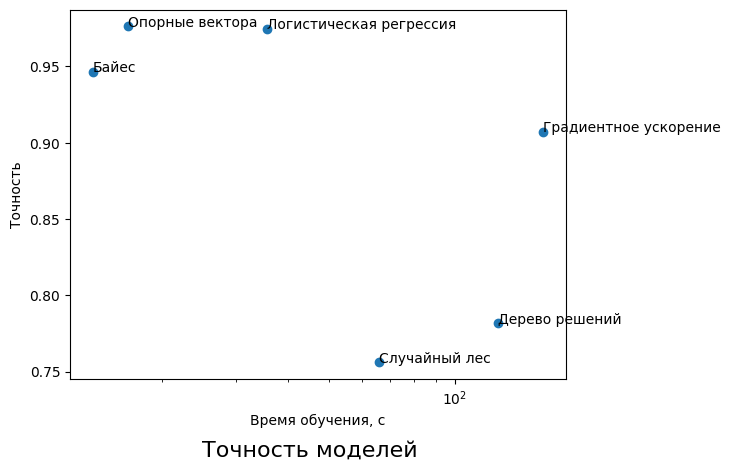

In [65]:
# Create the plot as requested

import matplotlib.pyplot as plt


models = ["Байес", "Логистическая регрессия", "Дерево решений", "Опорные вектора", "Градиентное ускорение", "Случайный лес"]
accuracy = [0.9463559901806914, 0.9747675962815405, 0.7816411123184032, 0.9762767113364723, 0.9070385126162018, 0.7560062779186285]
time_sec = [13.65663743019104, 35.54560589790344, 126.84595847129822, 16.590663194656372, 162.83224296569824, 65.89334487915039]

plt.figure()


plt.scatter(time_sec, accuracy)


for i, model in enumerate(models):
    plt.annotate(model, (time_sec[i], accuracy[i]))


plt.xscale('log')

plt.xlabel("Время обучения, с")
plt.ylabel("Точность")
plt.figtext(
    0.5,
    -0.05,
    "Точность моделей",
    ha='center',
    fontsize=16
)

plt.show()

In [42]:
from pyspark.sql import functions as F
from pyspark.sql.types import StringType, ArrayType, IntegerType, StructType,StructField
import numpy as np
from math import log, exp
from pyspark.sql import SparkSession
import os
import sys
import pandas as pd
import time

spark.stop()

spark = SparkSession.builder \
    .appName("SpamFilter") \
    .config("spark.driver.memory", "12g") \
    .config("spark.executor.memory", "24g") \
    .config("spark.executor.cores", "12") \
    .config("spark.executor.instances", "12") \
    .config("spark.default.parallelism", "32") \
    .config("spark.sql.shuffle.partitions", "32") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer") \
    .config("spark.kryoserializer.buffer.max", "512m") \
    .config("spark.sql.inMemoryColumnarStorage.compressed", "true") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true") \
    .config("spark.dynamicAllocation.enabled", "false") \
    .config("spark.driver.extraJavaOptions", 
            "--add-opens=java.base/java.lang=ALL-UNNAMED "
            "--add-opens=java.base/java.nio=ALL-UNNAMED "
            "--add-opens=java.base/java.util=ALL-UNNAMED "
            "-XX:+UseG1GC "  # Использовать Garbage Collector G1
            "-XX:+IgnoreUnrecognizedVMOptions") \
    .config("spark.executor.extraJavaOptions", 
            "--add-opens=java.base/java.lang=ALL-UNNAMED "
            "--add-opens=java.base/java.nio=ALL-UNNAMED "
            "--add-opens=java.base/java.util=ALL-UNNAMED "
            "-XX:+UseG1GC "
            "-XX:+IgnoreUnrecognizedVMOptions") \
    .getOrCreate()

schema = StructType([
    StructField("label", IntegerType(), True),  # Метка как целое число
    StructField("email", StringType(), True)    # Текст письма как строка
])
pdf = pd.read_csv("translated_and_english_combined_file.csv")

df = spark.createDataFrame(pdf)

df = df.withColumn(
    "label",
    F.when(F.col("label").isNull(), 0)
     .when(F.col("label") >= 1, 1)
     .otherwise(0)
)

In [43]:
from pyspark.ml.feature import Tokenizer, StopWordsRemover, CountVectorizer
from pyspark.ml.classification import LinearSVC  # Импорт SVM
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Фильтрация пустых значений
svm_start = time.time()
df = df.filter(df.email.isNotNull())

# 1. Токенизация
tokenizer = Tokenizer(inputCol="email", outputCol="words")

# 2. Удаление стоп-слов
remover = StopWordsRemover(inputCol="words", outputCol="filtered")

# 3. Векторизация
vectorizer = CountVectorizer(
    inputCol="filtered", 
    outputCol="features",
    vocabSize=100_000_000, 
    minDF=1
)

# 4. Классификатор SVM (LinearSVC)
svm = LinearSVC(
    featuresCol="features", 
    labelCol="label",
    maxIter=100,          # Количество итераций
    regParam=0.1,         # Параметр регуляризации   # <-- добавляем
)
# 5. Пайплайн
pipeline = Pipeline(stages=[tokenizer, remover, vectorizer, svm])

# 6. Разделение на train/test
train_data, test_data = df.randomSplit([0.7, 0.3], seed=42)

# 7. Обучение модели
svm_model = pipeline.fit(train_data)

# 8. Предсказания
predictions = svm_model.transform(test_data)

# 9. Оценка качества
evaluator = MulticlassClassificationEvaluator(
    labelCol="label", 
    predictionCol="prediction", 
    metricName="accuracy"
)
svm_accuracy = evaluator.evaluate(predictions)
print(f"SVM Accuracy: {svm_accuracy:.4f}")
svm_end = time.time()
# Дополнительные метрики (F1, Precision, Recall)
evaluator.setMetricName("f1").evaluate(predictions)
evaluator.setMetricName("weightedPrecision").evaluate(predictions)
evaluator.setMetricName("weightedRecall").evaluate(predictions)

26/05/21 22:37:21 WARN TaskSetManager: Stage 0 contains a task of very large size (16516 KiB). The maximum recommended task size is 1000 KiB.
26/05/21 22:37:27 WARN TaskSetManager: Stage 4 contains a task of very large size (16516 KiB). The maximum recommended task size is 1000 KiB.
26/05/21 22:37:31 WARN TaskSetManager: Stage 7 contains a task of very large size (16516 KiB). The maximum recommended task size is 1000 KiB.
26/05/21 22:37:34 WARN TaskSetManager: Stage 10 contains a task of very large size (16516 KiB). The maximum recommended task size is 1000 KiB.
26/05/21 22:37:34 WARN TaskSetManager: Stage 13 contains a task of very large size (16516 KiB). The maximum recommended task size is 1000 KiB.
26/05/21 22:37:35 WARN TaskSetManager: Stage 16 contains a task of very large size (16516 KiB). The maximum recommended task size is 1000 KiB.
26/05/21 22:37:35 WARN TaskSetManager: Stage 19 contains a task of very large size (16516 KiB). The maximum recommended task size is 1000 KiB.
26

SVM Accuracy: 0.9782


26/05/21 22:38:28 WARN TaskSetManager: Stage 612 contains a task of very large size (16516 KiB). The maximum recommended task size is 1000 KiB.
26/05/21 22:38:29 WARN DAGScheduler: Broadcasting large task binary with size 4.6 MiB
26/05/21 22:38:29 WARN TaskSetManager: Stage 614 contains a task of very large size (16516 KiB). The maximum recommended task size is 1000 KiB.
26/05/21 22:38:30 WARN DAGScheduler: Broadcasting large task binary with size 4.6 MiB
26/05/21 22:38:30 WARN TaskSetManager: Stage 616 contains a task of very large size (16516 KiB). The maximum recommended task size is 1000 KiB.
                                                                                

0.9781882570727192

In [44]:
svm_model.write().overwrite().save("models/spam_model_svm_ru")

26/05/21 22:38:34 WARN TaskSetManager: Stage 622 contains a task of very large size (14222 KiB). The maximum recommended task size is 1000 KiB.
26/05/21 22:38:36 WARN TaskSetManager: Stage 624 contains a task of very large size (4719 KiB). The maximum recommended task size is 1000 KiB.


In [45]:
print("SVM:", svm_accuracy, 'time', svm_end - svm_start)

SVM: 0.9781882570727192 time 66.7970609664917


In [46]:
from pyspark.sql import functions as F
from pyspark.sql.types import StringType, ArrayType, IntegerType, StructType,StructField
import numpy as np
from math import log, exp
from pyspark.sql import SparkSession
import os
import sys
import pandas as pd
import time

spark.stop()

spark = SparkSession.builder \
    .appName("SpamFilter") \
    .config("spark.driver.memory", "12g") \
    .config("spark.executor.memory", "24g") \
    .config("spark.executor.cores", "12") \
    .config("spark.executor.instances", "12") \
    .config("spark.default.parallelism", "32") \
    .config("spark.sql.shuffle.partitions", "32") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer") \
    .config("spark.kryoserializer.buffer.max", "512m") \
    .config("spark.sql.inMemoryColumnarStorage.compressed", "true") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true") \
    .config("spark.dynamicAllocation.enabled", "false") \
    .config("spark.driver.extraJavaOptions",
            "--add-opens=java.base/java.lang=ALL-UNNAMED "
            "--add-opens=java.base/java.nio=ALL-UNNAMED "
            "--add-opens=java.base/java.util=ALL-UNNAMED "
            "-XX:+UseG1GC "  # Использовать Garbage Collector G1
            "-XX:+IgnoreUnrecognizedVMOptions") \
    .config("spark.executor.extraJavaOptions",
            "--add-opens=java.base/java.lang=ALL-UNNAMED "
            "--add-opens=java.base/java.nio=ALL-UNNAMED "
            "--add-opens=java.base/java.util=ALL-UNNAMED "
            "-XX:+UseG1GC "
            "-XX:+IgnoreUnrecognizedVMOptions") \
    .getOrCreate()

schema = StructType([
    StructField("label", IntegerType(), True),  # Метка как целое число
    StructField("email", StringType(), True)    # Текст письма как строка
])
pdf = pd.read_csv("russian_data.csv")

df = spark.createDataFrame(pdf)

df = df.withColumn(
    "label",
    F.when(F.col("label").isNull(), 0)
     .when(F.col("label") >= 1, 1)
     .otherwise(0)
)

In [47]:
from pyspark.ml.feature import Tokenizer, StopWordsRemover, CountVectorizer
from pyspark.ml.classification import LogisticRegression
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
lr_start = time.time()
df = df.filter(df.email.isNotNull())
# 1. Токенизация
tokenizer = Tokenizer(inputCol="email", outputCol="words")
# 2. Удаление стоп-слов
remover = StopWordsRemover(inputCol="words", outputCol="filtered",locale='ru')
# 3. Векторизация
vectorizer = CountVectorizer(inputCol="filtered", outputCol="features",vocabSize=100000, minDF=1)
# 4. Классификатор
lr = LogisticRegression(featuresCol="features", labelCol="label")

# 5. Пайплайн
pipeline = Pipeline(stages=[tokenizer, remover, vectorizer, lr])

# 6. Разделение на train/test
train_data, test_data = df.randomSplit([0.7, 0.3], seed=42)

# 7. Обучение
lr_model = pipeline.fit(train_data)

# 8. Предсказания
predictions = lr_model.transform(test_data)

# 9. Оценка качества
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
lr_accuracy = evaluator.evaluate(predictions)
print(f"Accuracy: {lr_accuracy:.4f}")
lr_end = time.time()

26/05/21 22:38:38 WARN TaskSetManager: Stage 0 contains a task of very large size (15704 KiB). The maximum recommended task size is 1000 KiB.
26/05/21 22:38:40 WARN TaskSetManager: Stage 4 contains a task of very large size (15704 KiB). The maximum recommended task size is 1000 KiB.
26/05/21 22:38:41 WARN TaskSetManager: Stage 7 contains a task of very large size (15704 KiB). The maximum recommended task size is 1000 KiB.
26/05/21 22:38:42 WARN TaskSetManager: Stage 10 contains a task of very large size (15704 KiB). The maximum recommended task size is 1000 KiB.
26/05/21 22:38:42 WARN TaskSetManager: Stage 13 contains a task of very large size (15704 KiB). The maximum recommended task size is 1000 KiB.
26/05/21 22:38:42 WARN TaskSetManager: Stage 16 contains a task of very large size (15704 KiB). The maximum recommended task size is 1000 KiB.
26/05/21 22:38:42 WARN TaskSetManager: Stage 19 contains a task of very large size (15704 KiB). The maximum recommended task size is 1000 KiB.
26

Accuracy: 0.9506


In [48]:
lr_model.write().overwrite().save("models/spam_model_lr_ru")

26/05/21 22:38:56 WARN TaskSetManager: Stage 367 contains a task of very large size (2534 KiB). The maximum recommended task size is 1000 KiB.


In [49]:
from pyspark.sql import functions as F
from pyspark.sql.types import StringType, ArrayType, IntegerType, StructType,StructField
import numpy as np
from math import log, exp
from pyspark.sql import SparkSession
import os
import sys
import pandas as pd
import time

spark.stop()

spark = SparkSession.builder \
    .appName("SpamFilter") \
    .config("spark.driver.memory", "12g") \
    .config("spark.executor.memory", "24g") \
    .config("spark.executor.cores", "12") \
    .config("spark.executor.instances", "12") \
    .config("spark.default.parallelism", "32") \
    .config("spark.sql.shuffle.partitions", "32") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer") \
    .config("spark.kryoserializer.buffer.max", "512m") \
    .config("spark.sql.inMemoryColumnarStorage.compressed", "true") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true") \
    .config("spark.dynamicAllocation.enabled", "false") \
    .config("spark.driver.extraJavaOptions",
            "--add-opens=java.base/java.lang=ALL-UNNAMED "
            "--add-opens=java.base/java.nio=ALL-UNNAMED "
            "--add-opens=java.base/java.util=ALL-UNNAMED "
            "-XX:+UseG1GC "  # Использовать Garbage Collector G1
            "-XX:+IgnoreUnrecognizedVMOptions") \
    .config("spark.executor.extraJavaOptions",
            "--add-opens=java.base/java.lang=ALL-UNNAMED "
            "--add-opens=java.base/java.nio=ALL-UNNAMED "
            "--add-opens=java.base/java.util=ALL-UNNAMED "
            "-XX:+UseG1GC "
            "-XX:+IgnoreUnrecognizedVMOptions") \
    .getOrCreate()

schema = StructType([
    StructField("label", IntegerType(), True),  # Метка как целое число
    StructField("email", StringType(), True)    # Текст письма как строка
])
pdf = pd.read_csv("translated_and_english_combined_file.csv")

df = spark.createDataFrame(pdf)

df = df.withColumn(
    "label",
    F.when(F.col("label").isNull(), 0)
     .when(F.col("label") >= 1, 1)
     .otherwise(0)
)

In [50]:
from pyspark.sql import functions as F
from pyspark.sql.types import StringType, ArrayType, IntegerType, StructType,StructField
import numpy as np
from math import log, exp
from pyspark.sql import SparkSession
import os
import sys
import pandas as pd
import time

spark.stop()

spark = SparkSession.builder \
    .appName("SpamFilter") \
    .config("spark.driver.memory", "12g") \
    .config("spark.executor.memory", "24g") \
    .config("spark.executor.cores", "12") \
    .config("spark.executor.instances", "12") \
    .config("spark.default.parallelism", "32") \
    .config("spark.sql.shuffle.partitions", "32") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer") \
    .config("spark.kryoserializer.buffer.max", "512m") \
    .config("spark.sql.inMemoryColumnarStorage.compressed", "true") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true") \
    .config("spark.dynamicAllocation.enabled", "false") \
    .config("spark.driver.extraJavaOptions",
            "--add-opens=java.base/java.lang=ALL-UNNAMED "
            "--add-opens=java.base/java.nio=ALL-UNNAMED "
            "--add-opens=java.base/java.util=ALL-UNNAMED "
            "-XX:+UseG1GC "  # Использовать Garbage Collector G1
            "-XX:+IgnoreUnrecognizedVMOptions") \
    .config("spark.executor.extraJavaOptions",
            "--add-opens=java.base/java.lang=ALL-UNNAMED "
            "--add-opens=java.base/java.nio=ALL-UNNAMED "
            "--add-opens=java.base/java.util=ALL-UNNAMED "
            "-XX:+UseG1GC "
            "-XX:+IgnoreUnrecognizedVMOptions") \
    .getOrCreate()

schema = StructType([
    StructField("label", IntegerType(), True),  # Метка как целое число
    StructField("email", StringType(), True)    # Текст письма как строка
])
pdf = pd.read_csv("translated_and_english_combined_file.csv")

df = spark.createDataFrame(pdf)

df = df.withColumn(
    "label",
    F.when(F.col("label").isNull(), 0)
     .when(F.col("label") >= 1, 1)
     .otherwise(0)
)

In [51]:
lr_model.write().overwrite().save("models/spam_model_lr_ru_big")

26/05/21 22:39:07 WARN TaskSetManager: Stage 4 contains a task of very large size (2534 KiB). The maximum recommended task size is 1000 KiB.


In [52]:
schema = StructType([
    StructField("label", IntegerType(), True),  # Метка как целое число
    StructField("email", StringType(), True)    # Текст письма как строка
])
pdf = pd.read_csv("combined_data.csv")

df = spark.createDataFrame(pdf)

df = df.withColumn(
    "label",
    F.when(F.col("label").isNull(), 0)
     .when(F.col("label") >= 1, 1)
     .otherwise(0)
)

26/05/21 22:56:26 WARN TaskSetManager: Stage 625 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/21 22:56:28 WARN TaskSetManager: Stage 641 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/21 22:56:31 WARN TaskSetManager: Stage 657 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/21 22:56:33 WARN TaskSetManager: Stage 673 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/21 22:56:36 WARN TaskSetManager: Stage 689 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/21 22:56:39 WARN TaskSetManager: Stage 707 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/21 22:56:42 WARN TaskSetManager: Stage 725 contains a task of very large size (16595 KiB). The maximum recommended task size is 10

                model_name  avg_prediction_time
4    Градиентное ускорение             0.000010
0                    Байес             0.000010
5            Случайный лес             0.000014
1  Логистическая регрессия             0.000015
2           Дерево решений             0.000017
3          Опорные вектора             0.000017


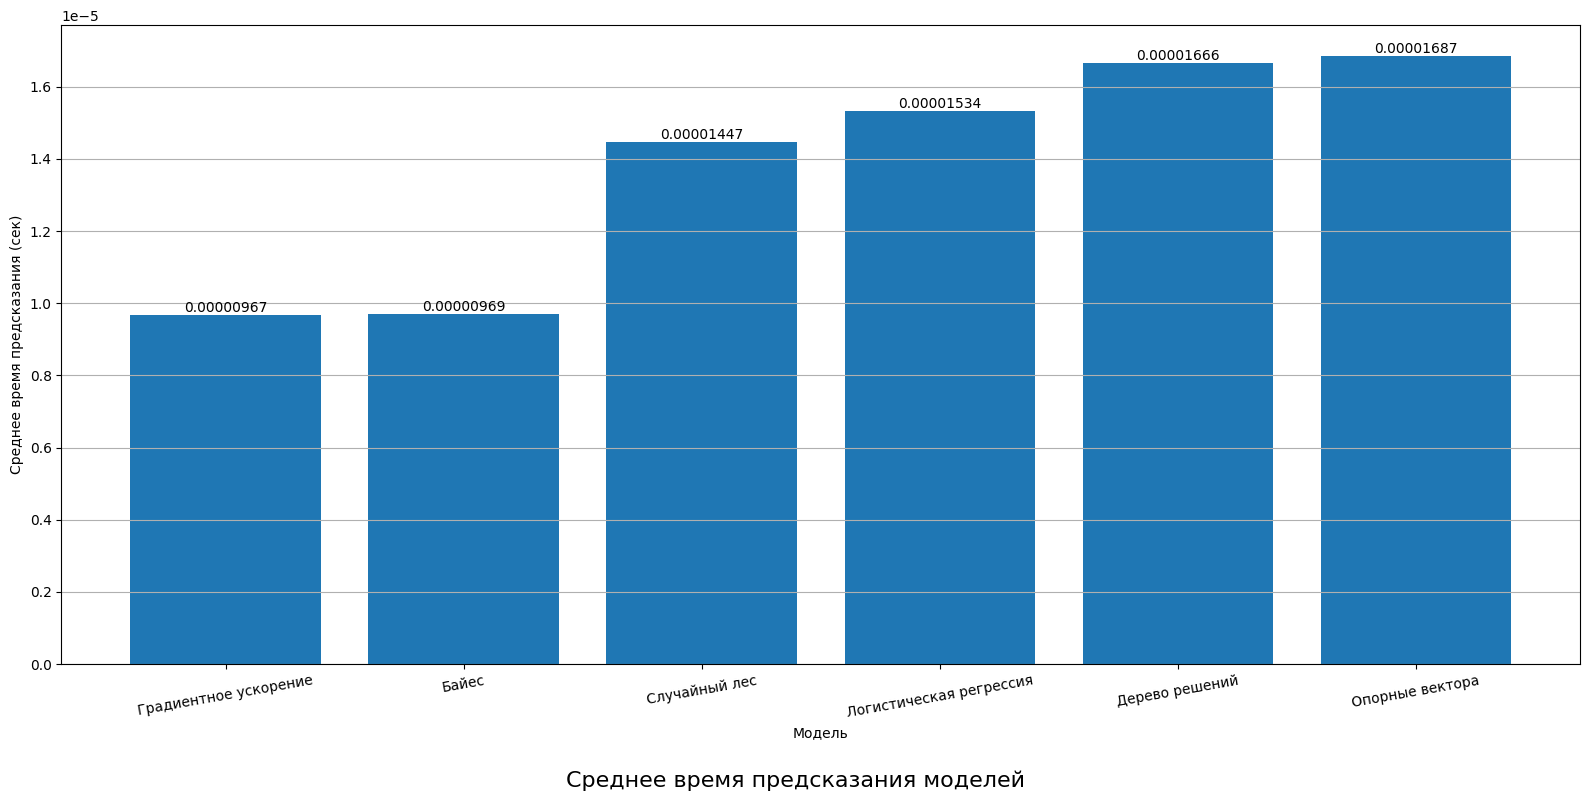

In [61]:
import time
import pandas as pd
import matplotlib.pyplot as plt

from pyspark.ml import PipelineModel

model_labels = {
    "bayes": "Байес",
    "lr": "Логистическая регрессия",
    "dt": "Дерево решений",
    "svm": "Опорные вектора",
    "gbt": "Градиентное ускорение",
    "rf": "Случайный лес"
}

model_keys = ["bayes", "lr", "dt", "svm", "gbt", "rf"]

results = []

train_data, test_data = df.randomSplit([0.7, 0.3], seed=42)

test_count = test_data.count()

for model_key in model_keys:

    model_path = f"models/spam_model_{model_key}"

    model = PipelineModel.load(model_path)

    start_time = time.time()

    predictions = model.transform(test_data)

    predictions.count()

    end_time = time.time()

    total_time = end_time - start_time
    avg_time = total_time / test_count

    results.append({
        "model_name": model_labels[model_key],
        "avg_prediction_time": avg_time
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="avg_prediction_time",
    ascending=True
)

print(results_df)

plt.figure(figsize=(16, 8))

bars = plt.bar(
    results_df["model_name"],
    results_df["avg_prediction_time"]
)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.8f}",
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.xlabel("Модель")
plt.ylabel("Среднее время предсказания (сек)")

plt.figtext(
    0.5,
    0.01,
    "Среднее время предсказания моделей",
    ha='center',
    fontsize=16
)

plt.xticks(rotation=10)

plt.grid(axis='y')

plt.tight_layout(rect=[0, 0.05, 1, 1])

plt.show()